# PEA-STA Analysis

In [1]:
cd /home/mscs/congfeng4/GuidedStudy/Code/SCOIT/

/home/mscs/congfeng4/GuidedStudy/Code/SCOIT


/public/congfeng4/miniconda3/envs/py39/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
import numpy as np
import seaborn as sns
from umap import UMAP
import pandas as pd
import json
import sys
import matplotlib.pyplot as plt

DATA = 'PEA_STA'
FEATURE = 'walk'
embedding_dir = f'./embeddings/{DATA}'

In [8]:
cell_embeddings = np.load(f'{embedding_dir}/mymodel_0.npy')
gene_embeddings = np.load(f'{embedding_dir}/mymodel_1.npy')
omics_embeddings = np.load(f'{embedding_dir}/mymodel_2.npy')

node_names = pd.read_csv(f'./data/{DATA}/nodes.csv')["Name"]
# cell_stage = np.unique(pd.read_csv(f"data/{DATA}/cell_stage.csv", header=None))
cell_stage = ['0h', '6d', 'BMP4']
metadata = json.load(open(f'./data/{DATA}/metadata.json'))

In [9]:
cell_stage, len(cell_stage)

(['0h', '6d', 'BMP4'], 3)

In [10]:
cell_names = node_names[metadata['cell_offset']:].values
cell_names

array(['u3035_0h_contol_A02', 'u3035_0h_contol_A03',
       'u3035_0h_contol_A04', 'u3035_0h_contol_A05',
       'u3035_0h_contol_A06', 'u3035_0h_contol_A07',
       'u3035_0h_contol_A08', 'u3035_0h_contol_A09',
       'u3035_0h_contol_A10', 'u3035_0h_contol_A11',
       'u3035_0h_contol_A12', 'u3035_0h_contol_B02',
       'u3035_0h_contol_B03', 'u3035_0h_contol_B04',
       'u3035_0h_contol_B05', 'u3035_0h_contol_B06',
       'u3035_0h_contol_B07', 'u3035_0h_contol_B08',
       'u3035_0h_contol_B09', 'u3035_0h_contol_B10',
       'u3035_0h_contol_B11', 'u3035_0h_contol_B12',
       'u3035_0h_contol_C02', 'u3035_0h_contol_C03',
       'u3035_0h_contol_C04', 'u3035_0h_contol_C05',
       'u3035_0h_contol_C06', 'u3035_0h_contol_C08',
       'u3035_0h_contol_C09', 'u3035_0h_contol_C10',
       'u3035_0h_contol_C11', 'u3035_0h_contol_C12',
       'u3035_0h_contol_D01', 'u3035_0h_contol_D02',
       'u3035_0h_contol_D03', 'u3035_0h_contol_D05',
       'u3035_0h_contol_D06', 'u3035_0h_contol

In [22]:
def find_cell_stage(cell_id):
    if '0h' in cell_id:
        return '0h untreated'
    if '6d' in cell_id:
        if 'contol' in cell_id:
            return '6d untreated'
        if 'BMP4' in cell_id:
            return '6d BMP4 treated'
    raise ValueError(cell_id)

cell_stage_from_id = [find_cell_stage(x) for x in cell_names]

In [25]:
# Check the stage and name.
assert len(cell_stage_from_id) == len(cell_names)

In [26]:
gene_names = node_names[metadata['gene_offset']: metadata['gene_offset'] + metadata['num_genes']].values
len(gene_names)

166

## Cell Embeddings

Text(0, 0.5, 'UMAP_2')

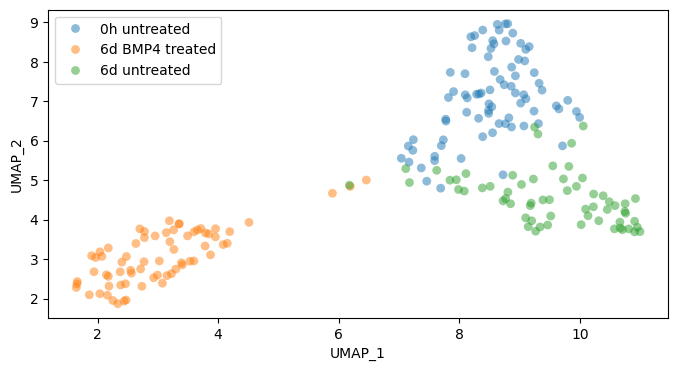

In [ ]:
S=40

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
vec = UMAP(n_components=2).fit_transform(cell_embeddings)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_stage_from_id,
                s=S, linewidth=0, alpha=0.5)
plt.legend()
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")


## Heatmaps of gene embeddings

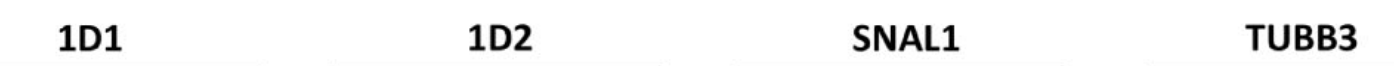
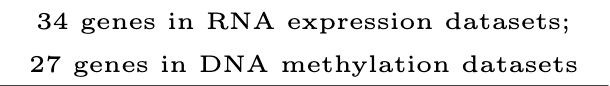

In [33]:
EXPR_LIST = [
    "1D1", "1D2", "SNAL1", "TUBB3"
]
import re
GENE_RE = re.compile('|'.join(EXPR_LIST))

In [37]:
gene_list = [
    "CAV1", "SOD1", "GFAP", "CASP8", "IKBKG", "VIM", "SMAD4", "CDKN1B",
    "PXN", "MIF", "SOD2", "ID1", "SOX2", "MELK", "PLAU", "XIAP", "PLCG1",
    "EGF", "TGFB1", "EGFR", "CDKN2C", "MKI67", "NPM1", "ERBB2", "EPHA2"
]


In [28]:
df_gene = pd.DataFrame(gene_embeddings.T, columns=gene_names)
df_gene

,AKT1_expr,AXIN2_expr,BAX_expr,BCL2_expr,BCL2L1_expr,BMI1_expr,BMP2_expr,BMP4_expr,BMPR1A_expr,BMPR1B_expr,...,SOX9_protein,TENASCIN.C_protein,TGFB1_protein,THY1_protein,TNFRSF10B_protein,TNFRSF1A_protein,TP53_protein,VEGFA_protein,VIM_protein,XIAP_protein
0,5.047740,0.840485,0.237452,-1.438898,0.899535,-0.028335,-0.588438,0.715894,-0.078673,1.253434,...,0.841761,0.167438,0.951970,-1.071267,-1.264835,-0.670440,0.906303,-0.042133,-0.116779,-0.198109
1,1.083639,0.532566,0.323056,-5.268723,-0.017439,-0.194474,0.239168,0.466960,0.309654,-0.011941,...,0.776089,0.223956,0.506996,1.158296,0.481230,0.759229,0.731251,0.284598,0.176089,1.133638
2,-3.292462,-0.358353,-0.397135,-0.394050,0.515547,-0.572693,-0.169294,-1.277622,0.033715,-0.740017,...,0.635331,0.491593,0.630702,-1.593951,-1.002561,-1.706474,-0.322461,-0.547682,0.401113,-1.195604
3,2.067062,0.199445,0.045443,5.308474,-0.250057,-0.187092,0.356227,0.353872,-0.003844,0.517723,...,-0.728339,-0.480607,-0.335753,0.194904,0.774639,1.498142,0.180757,0.716520,-0.615431,0.696166
4,4.658889,-0.056179,-0.152565,3.939234,-0.004200,-0.278679,-0.228399,-0.517591,-0.118013,-0.377715,...,0.146557,-0.054078,0.163300,-0.293331,-0.340629,-0.476491,-0.221423,-0.283171,0.163422,-0.242750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,-4.351845,-0.029822,0.182387,0.006465,0.923624,0.367515,-0.647099,-0.237548,-0.638933,0.755214,...,0.785640,0.719252,-0.875442,1.865407,-0.145906,-0.144538,0.208071,-0.142374,1.286775,2.435825
60,-3.727449,0.699503,0.688379,-2.825875,0.246684,0.236607,0.743132,1.195573,-0.028012,0.857335,...,-0.109080,-0.080483,-0.483462,0.953819,1.791496,1.697385,0.611898,0.105274,-0.426416,0.534815
61,9.387176,-0.269081,-0.261197,3.572889,-0.419031,-0.290836,-0.108386,-0.461019,0.027230,-0.100402,...,-0.062694,-0.178232,-0.408070,0.733705,-0.031390,-0.114648,-0.056315,0.030423,-0.137886,0.195506
62,-3.386947,-0.422818,-0.037145,2.714758,0.019544,-0.555742,-0.683104,-0.971920,-0.029091,-0.225658,...,-0.174902,-0.058109,0.101464,-1.024631,-0.874067,-1.523083,-0.436230,-0.635852,0.416141,-0.445797


## C. Protein and RNA correlations

In [38]:
df_expr = df_gene.loc[:, df_gene.columns.str.endswith('_expr')].rename(lambda x: x.replace('_expr', ''), axis=1)
df_expr = df_expr.loc[:, gene_list]

In [63]:
df_protein = df_gene.loc[:, df_gene.columns.str.endswith('_protein')].rename(lambda x: x.replace('_protein', ''), axis=1)
df_protein = df_protein.loc[:, gene_list]

In [65]:
df_corr = df_expr.corrwith(df_protein, method='pearson')

Text(0.5, 0, 'Pearson correlation coefficients')

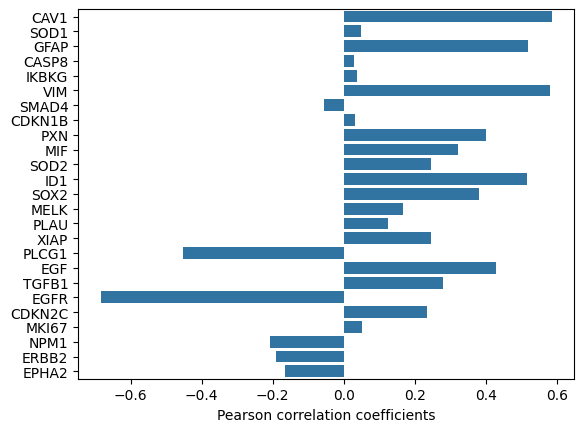

In [69]:
sns.barplot(df_corr, orient='h')
plt.xlabel('Pearson correlation coefficients')

In [78]:
df_cell = pd.DataFrame(cell_embeddings, index=cell_names)


Text(0.5, 1.0, 'CAV1')

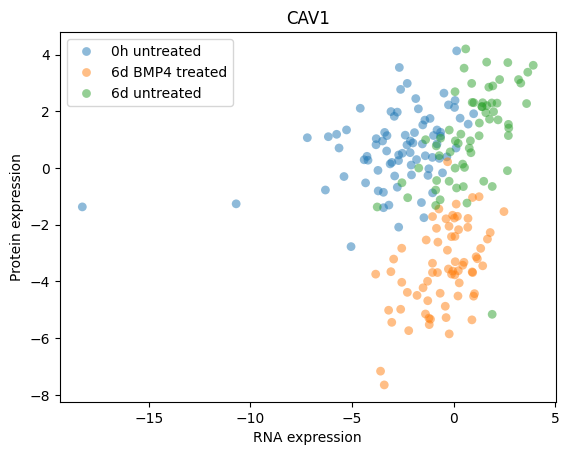

In [84]:
GENE = 'CAV1'
sns.scatterplot(x=df_cell @ df_expr[GENE].T, y=df_cell @ df_protein[GENE].T,
                hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.xlabel('RNA expression')
plt.ylabel('Protein expression')
plt.title(GENE)

Text(0.5, 1.0, 'SOD1')

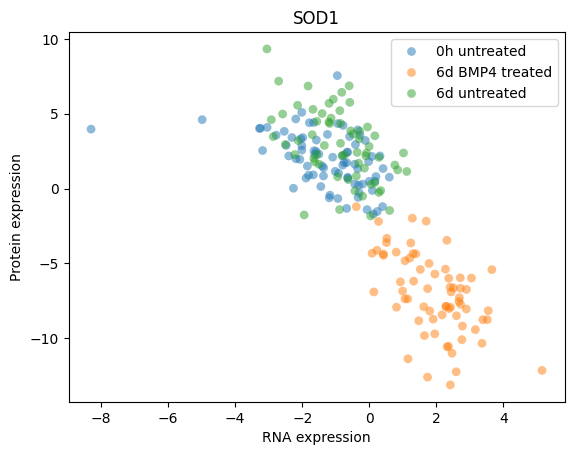

In [85]:
GENE = 'SOD1'
sns.scatterplot(x=df_cell @ df_expr[GENE].T, y=df_cell @ df_protein[GENE].T,
                hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.xlabel('RNA expression')
plt.ylabel('Protein expression')
plt.title(GENE)

Text(0.5, 1.0, 'ERBB2')

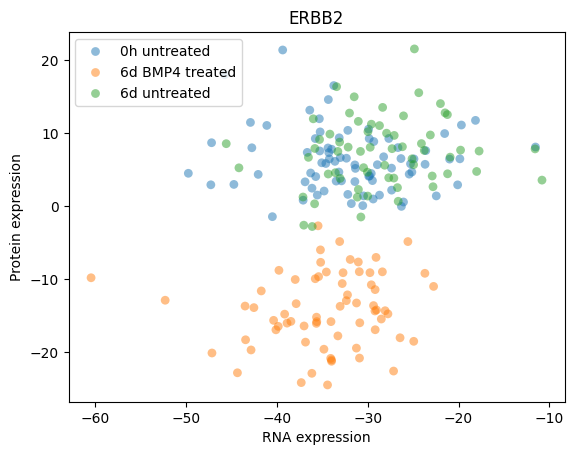

In [86]:
GENE = 'ERBB2'
sns.scatterplot(x=df_cell @ df_expr[GENE].T, y=df_cell @ df_protein[GENE].T,
                hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.xlabel('RNA expression')
plt.ylabel('Protein expression')
plt.title(GENE)

Text(0.5, 1.0, 'EPHA2')

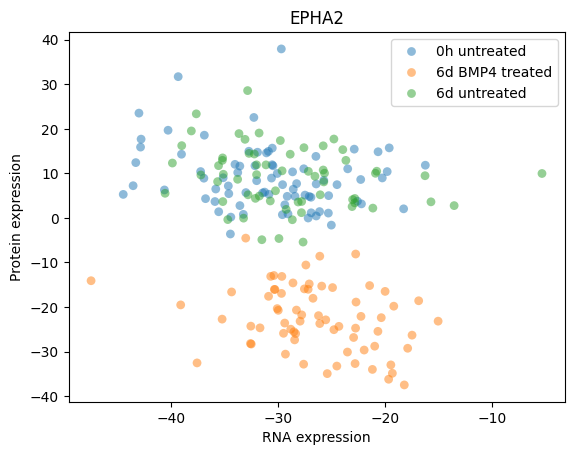

In [87]:
GENE = 'EPHA2'
sns.scatterplot(x=df_cell @ df_expr[GENE].T, y=df_cell @ df_protein[GENE].T,
                hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.xlabel('RNA expression')
plt.ylabel('Protein expression')
plt.title(GENE)

## Heatmap of DNA Methylation

In [16]:
df_methy = df_gene.loc[:, df_gene.columns.str.endswith('_methy')].rename(lambda x: x.replace('_methy', ''), axis=1)
df_methy = df_methy.loc[:, METHY_LIST]

Text(0.5, 1.0, 'Pearson correlations heatmap of DNA methylation on sc-GEM')

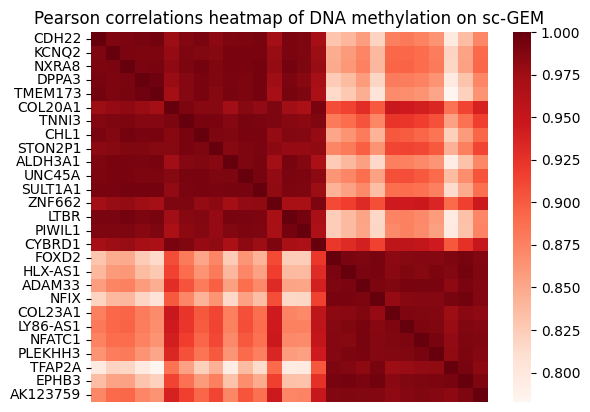

In [17]:
sns.heatmap(df_methy.corr(method='pearson'), cmap='Reds', yticklabels=METHY_LIST)
plt.xticks([])
plt.title('Pearson correlations heatmap of DNA methylation on sc-GEM')

## Projection of pluripotency and somatic gene embeddings

In [18]:
pluripotency = ["ZIC3", "KCNQ2", "ZFP42", "OTX2", "SALL4", "NANOG", "SOX2", "CDH1",
    "BMP7", "PRDM14", "DNMT3B", "TFCP2L1", "MMP9", "FGF4", "LEFTY",
    "WNT10B", "OCT4", "ZSCAN18", "CER1",]

intermedia = [
     'IGF2',
    'HAND1',
]

somatic = [
     'TFAP2A',
     'TBX3',
     'FOSL1',
     'LUM',
     'TGFBR2'
]

In [19]:
pluripotency_gene_df = df_expr.loc[:, pluripotency]
somatic_gene_df = df_expr.loc[:, somatic]

In [20]:
cell_norms = np.linalg.norm(cell_embeddings, axis=1).reshape((-1, 1))
cell_df = pd.DataFrame(cell_embeddings / cell_norms, index=cell_names)


In [21]:
np.sum(cell_df.iloc[0, :].values ** 2) # Cell embeddings normalized.

1.0

In [22]:
special_cell_stages = ['BJ', 'd8', 'd16', 'd24', 'IPS', 'ES']
special_cell_ids = [x for x in cell_df.index if any(stage in x for stage in special_cell_stages)]

In [23]:
special_cells_df = cell_df.loc[special_cell_ids, :].reset_index(names='cell_id')

In [24]:
def find_stage(cell_id):
    for stage in special_cell_stages:
        if stage in cell_id:
            return stage
    return '??'

special_cells_df['stage'] = special_cells_df['cell_id'].apply(find_stage)
special_cells_df = special_cells_df.drop(columns='cell_id').set_index('stage')

### Somatic projection

In [25]:
proj_somatic = (special_cells_df @ somatic_gene_df)
proj_somatic = pd.melt(proj_somatic.reset_index(), id_vars='stage')
proj_somatic


,stage,variable,value
0,BJ,TFAP2A,1.113576
1,BJ,TFAP2A,1.150314
2,BJ,TFAP2A,1.103441
3,BJ,TFAP2A,1.092116
4,BJ,TFAP2A,1.087973
...,...,...,...
1115,d8,TGFBR2,1.100231
1116,d8,TGFBR2,1.108776
1117,d8,TGFBR2,1.061827
1118,d8,TGFBR2,1.081262


Text(0, 0.5, 'Projection value')

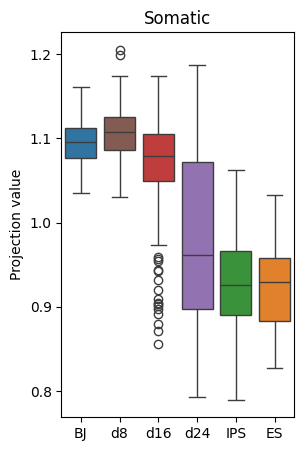

In [26]:
plt.figure(figsize=(3,5))
sns.boxplot(proj_somatic, x='stage', y='value', order=special_cell_stages, hue='stage')
plt.title('Somatic')
plt.xlabel('')
plt.ylabel('Projection value')


### Pluripotency projection

In [27]:
proj_pluripotency = (special_cells_df @ pluripotency_gene_df)
proj_pluripotency = pd.melt(proj_pluripotency.reset_index(), id_vars='stage')
proj_pluripotency


,stage,variable,value
0,BJ,ZIC3,0.937633
1,BJ,ZIC3,0.852532
2,BJ,ZIC3,0.944583
3,BJ,ZIC3,0.876058
4,BJ,ZIC3,0.997195
...,...,...,...
4251,d8,CER1,1.080613
4252,d8,CER1,1.062895
4253,d8,CER1,1.015988
4254,d8,CER1,0.952541


Text(0, 0.5, 'Projection value')

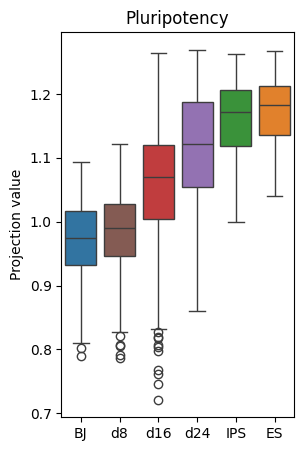

In [28]:
plt.figure(figsize=(3,5))
sns.boxplot(proj_pluripotency, x='stage', y='value', order=special_cell_stages, hue='stage')
plt.title('Pluripotency')
plt.xlabel('')
plt.ylabel('Projection value')

## Cell Clustering

In [29]:
cell_embeddings.shape

(224, 64)

In [ ]:
from sklearn.cluster import k_means

_, cluster, _ = k_means(UMAP(3).fit_transform(cell_embeddings / cell_norms), n_clusters=len(cell_stage))
cluster.shape

(224,)

In [31]:
cell_stage_ids = {lbl : i for i, lbl in enumerate(cell_stage)}

In [32]:
cell_stage_label = [cell_stage_ids[y] for y in cell_stage_from_id]

In [33]:
from scipy.optimize import linear_sum_assignment

k = len(cell_stage)
y = cell_stage_label
cluster_ids = cluster

def align_cluster(cluster_ids, y, k):
    # ---------- 3. build cost matrix ----------
    contingency = np.zeros((k, k), dtype=int)
    for c, gt in zip(cluster_ids, y):
        contingency[c, gt] += 1

    # cost = number of mismatches if we map cluster c -> class j
    cost_matrix = contingency.max() - contingency        # or: -contingency

    # ---------- 4. Hungarian ----------
    row_ind, col_ind = linear_sum_assignment(cost_matrix)   # same API as old linear_assignment

    # ---------- 5. remap ----------
    # build a dictionary  old_label -> new_label
    mapping = dict(zip(row_ind, col_ind))
    y_pred_aligned = np.vectorize(mapping.get)(cluster_ids)
    return y_pred_aligned


In [34]:
from sklearn.metrics import normalized_mutual_info_score # NMI
from sklearn.metrics import adjusted_rand_score # ARI
from sklearn.metrics import fowlkes_mallows_score # FMI

In [35]:
def compute_clustering_metrics(y_true, y_pred_aligned):
    return dict(
        NMI = normalized_mutual_info_score(y_true, y_pred_aligned),
        ARI = adjusted_rand_score(y_true, y_pred_aligned),
        FMI = fowlkes_mallows_score(y_true, y_pred_aligned),
    )

In [36]:
y_pred_aligned = align_cluster(cluster, cell_stage_label, len(cell_stage))

In [37]:
metrics = compute_clustering_metrics(y, y_pred_aligned)
metrics


{'NMI': 0.35978131051951867,
 'ARI': 0.17412964118406585,
 'FMI': 0.29131644247981386}

### Baselines

t-SNE, PCA, UMAP.

In [44]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

from scoit.cell_analysis import RunLeiden, RunLouvain, knn_adj_matrix

In [39]:
from hgnn.hypergraph import HyperGraphCreator
from pathlib import Path

create = HyperGraphCreator({
        'expr': './data/sc_GEM/expression_data.csv',
        'methy': './data/sc_GEM/methylation_data.csv',
    }, cell_key='Cell ID', dataname='sc_GEM', prefix=Path('./data'))

In [ ]:
create.load_and_preprocess_data()

Begin to load multi omics data {'expr': './data/sc_GEM/expression_data.csv', 'methy': './data/sc_GEM/methylation_data.csv'}
Load data done, time: 0.009735345840454102
Rename columns
Name: expr, Columns: Index(['ADAM33_expr', 'AFP_expr', 'AK123759_expr', 'ALDH3A1_expr', 'BMP7_expr',
       'CDH1_expr', 'CDH22_expr', 'CDX2_expr', 'CER1_expr', 'CHL1_expr',
       'COL20A1_expr', 'COL23A1_expr', 'CYBRD1_expr', 'DAZL_expr',
       'DNMT3B_expr', 'DNMT3L_expr', 'DPPA3_expr', 'EPHB3_expr', 'FGF4_expr',
       'FOSL1_expr', 'FOXD2_expr', 'HAND1_expr', 'HLX-AS1_expr', 'IGF2_expr',
       'JARID2_expr', 'KCNQ2_expr', 'LEFTY_expr', 'LTBR_expr', 'LUM_expr',
       'LY86-AS1_expr', 'MMP9_expr', 'MYC_expr', 'NANOG_expr', 'NESTIN_expr',
       'NFATC1_expr', 'NFIX_expr', 'NKX2-5_expr', 'NXRA8_expr', 'OCT4_expr',
       'OTX2_expr', 'PIWIL1_expr', 'PLEKHH3_expr', 'PRDM14_expr', 'SALL4_expr',
       'SOX2_expr', 'STON2P1_expr', 'SULT1A1_expr', 'TBX3_expr', 'TFAP2A_expr',
       'TFCP2L1_expr', 'TGFBR2_

,AFP_expr,BMP7_expr,CDH1_expr,CDX2_expr,CER1_expr,DAZL_expr,DNMT3B_expr,DNMT3L_expr,FGF4_expr,FOSL1_expr,HAND1_expr,IGF2_expr,JARID2_expr,KCNQ2_expr,LEFTY_expr,LUM_expr,MMP9_expr,MYC_expr,NANOG_expr,NESTIN_expr,NKX2-5_expr,OCT4_expr,OTX2_expr,PRDM14_expr,SALL4_expr,SOX2_expr,TBX3_expr,TFAP2A_expr,TFCP2L1_expr,TGFBR2_expr,WNT10B_expr,ZFP42_expr,ZIC3_expr,ZSCAN18_expr,ADAM33_methy,AK123759_methy,ALDH3A1_methy,CDH22_methy,CHL1_methy,COL20A1_methy,COL23A1_methy,CYBRD1_methy,DPPA3_methy,EPHB3_methy,FOXD2_methy,HLX-AS1_methy,KCNQ2_methy,LTBR_methy,LY86-AS1_methy,NFATC1_methy,NFIX_methy,NXRA8_methy,PIWIL1_methy,PLEKHH3_methy,STON2P1_methy,SULT1A1_methy,TFAP2A_methy,TMEM173_methy,TNNI3_methy,UNC45A_methy,ZNF662_methy
Cell ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
BJ_1,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,16.728549,0.000000,0.000000,11.339771,0.0,0.0,15.676021,0.0,17.672202,0.000000,0.000000,0.0,0.0,0.000000,0.0,4.113456,0.000000,18.862732,18.263900,0.0,0.000000,0.000000,0.0,0.0,0.0,1,0,0,0,0,0,1,0,0,1,1,0,0,0,1,1,1,0,0,1,1,1,1,0,0,0,0
BJ_11,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,18.601503,0.000000,0.000000,0.000000,0.0,0.0,14.837929,0.0,17.923791,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,20.198281,19.781943,0.0,0.000000,0.000000,0.0,0.0,0.0,1,1,0,0,0,0,1,0,0,1,1,1,0,0,1,1,1,0,0,1,0,0,1,0,0,0,0
BJ_12,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,15.460834,0.000000,0.000000,14.112148,0.0,0.0,0.000000,0.0,17.893047,0.000000,4.826607,0.0,0.0,0.000000,0.0,0.000000,0.000000,19.193395,18.370780,0.0,4.767891,0.000000,0.0,0.0,0.0,1,0,0,0,1,1,1,0,0,1,1,1,0,0,1,1,1,0,0,1,0,0,1,1,1,0,0
BJ_13,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,18.178236,0.000000,0.000000,0.000000,0.0,0.0,16.516569,0.0,20.464720,0.000000,8.418421,0.0,0.0,0.000000,0.0,0.000000,8.111852,21.272866,17.711377,0.0,0.000000,0.000000,0.0,0.0,0.0,1,0,0,0,1,0,1,0,0,1,1,1,1,0,1,1,1,0,0,1,0,0,1,0,0,0,0
BJ_14,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,17.713610,0.000000,0.000000,0.000000,0.0,0.0,19.545398,0.0,19.270543,0.000000,2.752524,0.0,0.0,0.000000,0.0,9.019616,0.000000,19.588199,20.853982,0.0,4.419259,8.796303,0.0,0.0,0.0,1,1,0,0,1,0,1,0,0,1,1,1,0,0,1,1,1,0,0,1,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
d8_46,0.0,0.0,18.865629,0.0,0.0,0.0,15.397756,19.233267,0.0,0.000000,17.288448,17.469698,0.000000,0.0,0.0,0.000000,0.0,24.366972,0.000000,11.291259,0.0,0.0,0.000000,0.0,0.000000,0.000000,18.700552,18.570520,0.0,0.000000,0.000000,0.0,0.0,0.0,1,1,0,0,0,1,1,0,1,1,1,1,0,0,1,1,1,0,0,1,0,0,1,0,0,0,0
d8_5,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,16.115367,0.000000,11.432820,17.093213,0.0,0.0,0.000000,0.0,24.101037,3.935607,13.656141,0.0,0.0,12.391728,0.0,11.596348,0.000000,16.747477,21.641471,0.0,5.239673,0.000000,0.0,0.0,0.0,1,1,0,0,0,1,1,1,0,1,1,1,0,0,1,1,1,0,0,1,0,0,1,0,0,1,0
d8_7,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,11.767016,0.000000,0.0,0.0,0.000000,0.0,21.850392,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,14.592632,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,1,1,0,0,0,0,1,0,0,1,1,1,0,0,1,1,1,1,0,1,1,0,1,0,0,0,0


In [41]:
assert (create.df.index == cell_names).all().all()


In [42]:
features = create.df.values
features.shape

(224, 61)

In [ ]:
baselines = {
    'TSNE' : TSNE,
    'PCA': PCA,
    'UMAP': UMAP,
    'Ours': None, # Placeholder
}

def run_baselines(features, cell_embeddings, dims=3):
    records = []

    for name, method in baselines.items():
        print(name)
        if method is None:
            x = cell_embeddings
        else:
            x = method(n_components=dims).fit_transform(features)

        x_norm = np.linalg.norm(x, axis=1).reshape((-1, 1))
        x = x / x_norm
        _, c, _ = k_means(x, k)
        c_aligned = align_cluster(c, cell_stage_label, k)
        kmeans_metrics = compute_clustering_metrics(cell_stage_label, c_aligned)
        for key, value in kmeans_metrics.items():
            records.append(dict(method=name, metric=key, value=value, task='kmeans'))

        adj = knn_adj_matrix(x)
        c = RunLeiden(adj)
        c_aligned = align_cluster(c, cell_stage_label, k)
        leiden_metrics = compute_clustering_metrics(cell_stage_label, c_aligned)
        for key, value in leiden_metrics.items():
            records.append(dict(method=name, metric=key, value=value, task='leiden'))

    return pd.DataFrame.from_records(records)


Text(0, 0.5, 'UMAP_2')

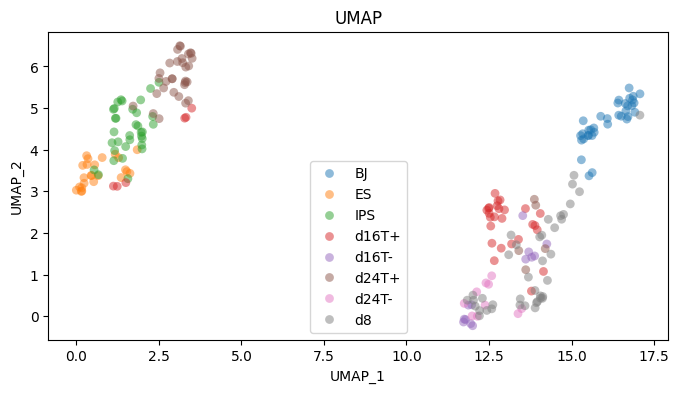

In [ ]:
S=40

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
vec = UMAP(n_components=2).fit_transform(features)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.legend()
plt.title('UMAP')
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")


Text(0, 0.5, 'TSNE_2')

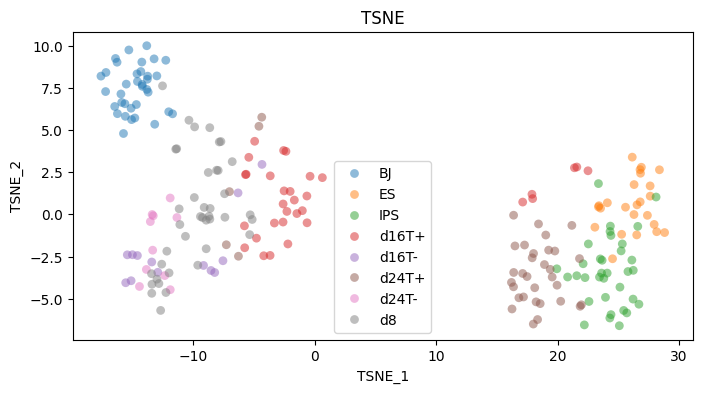

In [ ]:
S=40

from umap import UMAP
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
vec = TSNE(n_components=2).fit_transform(features)
sns.scatterplot(x=vec[:, 0], y=vec[:, 1], hue=cell_stage_from_id, s=S, linewidth=0, alpha=0.5)
plt.legend()
plt.title('TSNE')
plt.xlabel("TSNE_1")
plt.ylabel("TSNE_2")


### K-means performance

In [51]:
df_cluster = run_baselines(features, cell_embeddings)

TSNE
PCA
UMAP
Ours


Text(0, 0.5, '')

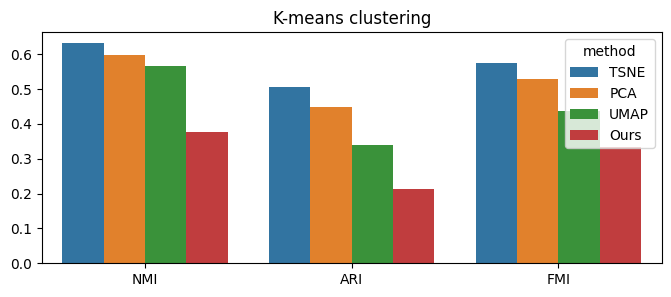

In [52]:
plt.figure(figsize=(8,3))
sns.barplot(df_cluster[df_cluster.task == 'kmeans'], x='metric', y='value', hue='method')
plt.title('K-means clustering')
plt.xlabel('')
plt.ylabel('')

### Leiden community detection

Text(0, 0.5, '')

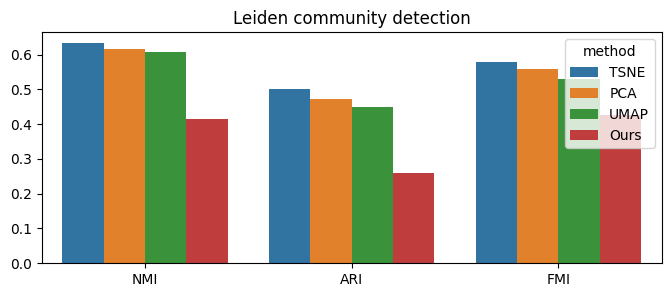

In [53]:
plt.figure(figsize=(8,3))
sns.barplot(df_cluster[df_cluster.task == 'leiden'], x='metric', y='value', hue='method')
plt.title('Leiden community detection')
plt.xlabel('')
plt.ylabel('')